## Chapter 5 — Classification

**Buku:** *Practical Statistics for Data Scientists* (O'Reilly)

## Tujuan
Chapter ini membahas *classification*, yaitu supervised learning untuk memprediksi apakah sebuah record termasuk ke dalam satu dari dua atau lebih kategori. Contoh utama buku menggunakan data pinjaman untuk memprediksi `default` atau `paid off`.


## Struktur Chapter 5

Bagian utama yang direproduksi:
1. Naive Bayes
2. Discriminant Analysis — terutama Linear Discriminant Analysis (LDA)
3. Logistic Regression
4. Evaluating Classification Models
5. Strategies for Imbalanced Data
6. Ringkasan dan analisis

Data utama: `loan_data.csv.gz` dari repository resmi buku.

In [1]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score,
    roc_curve, roc_auc_score, precision_recall_curve, auc
)

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

BASE = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"

## 1. Memuat Data

Dataset `loan_data.csv.gz` berisi data pinjaman. Variabel `outcome` digunakan sebagai target klasifikasi, dengan kategori `default` dan `paid off`. Buku menggunakan beberapa variabel seperti `payment_inc_ratio`, `purpose_`, `home_`, `emp_len_`, dan `borrower_score`.

In [2]:
loan_data = pd.read_csv(BASE + "loan_data.csv.gz")

print("Shape:", loan_data.shape)
display(loan_data.head())
print("\nKolom:")
print(loan_data.columns.tolist())
print("\nDistribusi outcome:")
display(loan_data["outcome"].value_counts())

Shape: (45342, 21)


,Unnamed: 0,status,loan_amnt,term,annual_inc,dti,payment_inc_ratio,revol_bal,revol_util,purpose,home_ownership,delinq_2yrs_zero,pub_rec_zero,open_acc,grade,outcome,emp_length,purpose_,home_,emp_len_,borrower_score
0,1,Charged Off,2500,60 months,30000,1.00,2.39320,1687,9.4,car,RENT,1,1,3,4.8,default,1,major_purchase,RENT,> 1 Year,0.65
1,2,Charged Off,5600,60 months,40000,5.55,4.57170,5210,32.6,small_business,OWN,1,1,11,1.4,default,5,small_business,OWN,> 1 Year,0.80
2,3,Charged Off,5375,60 months,15000,18.08,9.71600,9279,36.5,other,RENT,1,1,2,6.0,default,1,other,RENT,> 1 Year,0.60
3,4,Charged Off,9000,36 months,30000,10.08,12.21520,10452,91.7,debt_consolidation,RENT,1,1,4,4.2,default,1,debt_consolidation,RENT,> 1 Year,0.50
4,5,Charged Off,10000,36 months,100000,7.06,3.90888,11997,55.5,other,RENT,1,1,14,5.4,default,4,other,RENT,> 1 Year,0.55



Kolom:
['Unnamed: 0', 'status', 'loan_amnt', 'term', 'annual_inc', 'dti', 'payment_inc_ratio', 'revol_bal', 'revol_util', 'purpose', 'home_ownership', 'delinq_2yrs_zero', 'pub_rec_zero', 'open_acc', 'grade', 'outcome', 'emp_length', 'purpose_', 'home_', 'emp_len_', 'borrower_score']

Distribusi outcome:


,count
outcome,
default,22671
paid off,22671


### Analisis awal

Perhatikan bahwa klasifikasi tidak hanya menghasilkan label, tetapi banyak algoritma juga menghasilkan probabilitas suatu record termasuk ke kelas tertentu. Probabilitas tersebut kemudian dapat diubah menjadi label menggunakan *cutoff*, misalnya 0.50.

,proportion
outcome,
default,0.5
paid off,0.5


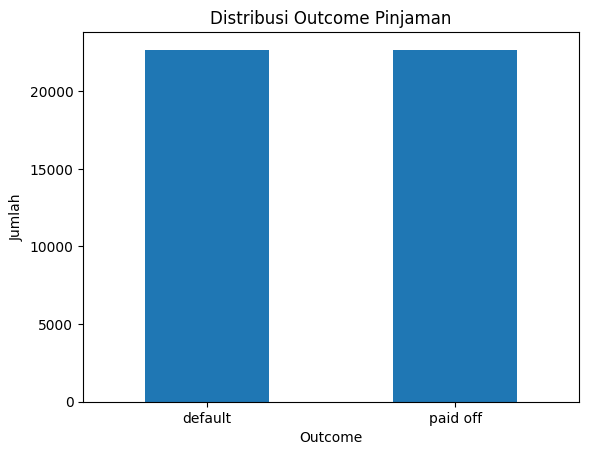

In [3]:
# Proporsi kelas
class_prop = loan_data["outcome"].value_counts(normalize=True).rename("proportion")
display(class_prop)

# Visualisasi sederhana
loan_data["outcome"].value_counts().plot(kind="bar")
plt.title("Distribusi Outcome Pinjaman")
plt.xlabel("Outcome")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

# 2. Naive Bayes

Naive Bayes menggunakan probabilitas bersyarat. Ide dasarnya adalah menghitung probabilitas suatu kelas berdasarkan nilai-nilai predictor.

Istilah penting:
- **Prior probability**: probabilitas kelas sebelum memperhitungkan predictor.
- **Conditional probability**: probabilitas predictor jika kelas sudah diketahui.
- **Posterior probability**: probabilitas kelas setelah informasi predictor diperhitungkan.

Asumsi utama Naive Bayes adalah bahwa predictor diperlakukan sebagai kondisi yang independen satu sama lain setelah kelas diketahui. Buku juga membahas bahwa predictor numerik perlu ditangani dengan pendekatan yang sesuai, misalnya distribusi probabilitas.

In [4]:
# Contoh Naive Bayes dengan tiga predictor kategorikal yang digunakan dalam pembahasan buku
nb_predictors = ["purpose_", "home_", "emp_len_"]
nb_target = "outcome"

nb_df = loan_data[nb_predictors + [nb_target]].dropna().copy()

# One-hot encoding
X_nb = pd.get_dummies(nb_df[nb_predictors], prefix="", prefix_sep="")
y_nb = nb_df[nb_target]

X_train, X_test, y_train, y_test = train_test_split(
    X_nb, y_nb, test_size=0.25, random_state=RANDOM_STATE, stratify=y_nb
)

nb_model = MultinomialNB(alpha=0.01, fit_prior=True)
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
nb_prob = nb_model.predict_proba(X_test)

print("Naive Bayes accuracy:", accuracy_score(y_test, nb_pred))
display(pd.DataFrame(
    confusion_matrix(y_test, nb_pred, labels=nb_model.classes_),
    index=["Actual: " + c for c in nb_model.classes_],
    columns=["Predicted: " + c for c in nb_model.classes_]
))

Naive Bayes accuracy: 0.5426958362738179


,Predicted: default,Predicted: paid off
Actual: default,2932,2736
Actual: paid off,2448,3220


### Interpretasi Naive Bayes

Model menghasilkan kelas prediksi dan probabilitas untuk setiap kelas. Nilai `alpha` pada `MultinomialNB` memberikan smoothing sehingga probabilitas tidak menjadi nol ketika kombinasi kategori tertentu tidak muncul pada data training.

In [5]:
# Probabilitas prediksi untuk beberapa record
nb_result = pd.DataFrame(nb_prob, columns=nb_model.classes_)
nb_result["actual"] = y_test.reset_index(drop=True)
nb_result["predicted"] = nb_pred
display(nb_result.head(10))

,default,paid off,actual,predicted
0,0.475885,0.524115,paid off,paid off
1,0.475885,0.524115,paid off,paid off
2,0.475885,0.524115,default,paid off
3,0.418455,0.581545,default,paid off
4,0.478213,0.521787,paid off,paid off
5,0.478213,0.521787,default,paid off
6,0.475885,0.524115,default,paid off
7,0.536282,0.463718,default,default
8,0.475885,0.524115,paid off,paid off
9,0.536282,0.463718,paid off,default


# 3. Discriminant Analysis

**Linear Discriminant Analysis (LDA)** mencari kombinasi linear predictor yang membantu memisahkan kelas.

Chapter menjelaskan covariance matrix sebagai bagian penting dalam discriminant analysis. LDA mengasumsikan struktur covariance yang sama antar kelas, sehingga batas keputusan yang dihasilkan bersifat linear.

In [6]:
# Gunakan dataset kecil yang berisi dua predictor utama dalam contoh klasifikasi loan
lda_cols = ["borrower_score", "payment_inc_ratio", "outcome"]
lda_df = loan_data[lda_cols].dropna().copy()

# Batasi ukuran data agar eksperimen cepat di Colab
if len(lda_df) > 10000:
    lda_df = lda_df.sample(10000, random_state=RANDOM_STATE)

X_lda = lda_df[["borrower_score", "payment_inc_ratio"]]
y_lda = lda_df["outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y_lda, test_size=0.25, random_state=RANDOM_STATE, stratify=y_lda
)

lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)

lda_pred = lda_model.predict(X_test)
lda_prob = lda_model.predict_proba(X_test)[:, list(lda_model.classes_).index("default")]

print("LDA accuracy:", accuracy_score(y_test, lda_pred))
print("LDA coefficients/scalings:")
display(pd.DataFrame(lda_model.scalings_, index=X_lda.columns))

LDA accuracy: 0.6344
LDA coefficients/scalings:


,0
borrower_score,6.760827
payment_inc_ratio,-0.119075


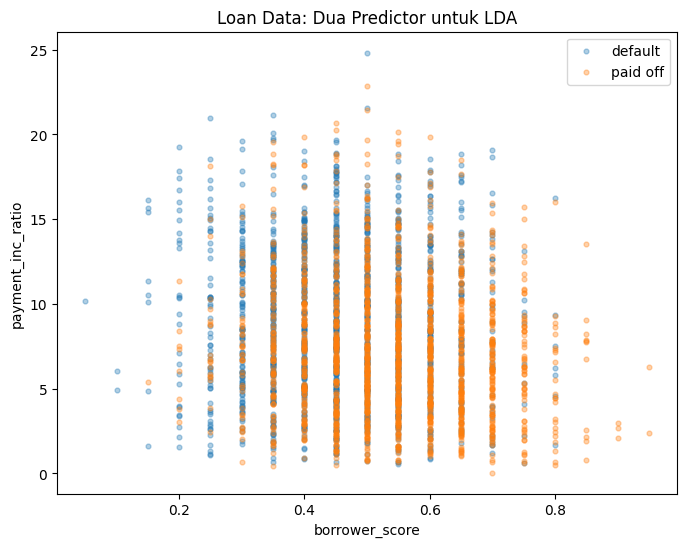

In [7]:
# Visualisasi decision regions sederhana untuk dua predictor
sample_plot = lda_df.sample(min(3000, len(lda_df)), random_state=RANDOM_STATE)

plt.figure(figsize=(8, 6))
for label, group in sample_plot.groupby("outcome"):
    plt.scatter(
        group["borrower_score"],
        group["payment_inc_ratio"],
        alpha=0.35,
        s=12,
        label=label
    )

plt.xlabel("borrower_score")
plt.ylabel("payment_inc_ratio")
plt.title("Loan Data: Dua Predictor untuk LDA")
plt.legend()
plt.show()

# 4. Logistic Regression

Logistic regression digunakan ketika outcome bersifat biner.

Model tidak memodelkan probabilitas secara langsung sebagai garis biasa. Probabilitas dipetakan melalui **logistic response function**:

$$
p = \frac{1}{1 + e^{-\left(\beta_0 + \beta_1x_1 + \cdots + \beta_qx_q\right)}}
$$

Hubungan ini dapat ditulis dalam bentuk **log odds / logit**:

$$
\log\left(\frac{p}{1-p}\right)
= \beta_0 + \beta_1x_1 + \cdots + \beta_qx_q
$$

Berbeda dari linear regression, logistic regression menggunakan **maximum likelihood estimation (MLE)** untuk memperoleh parameter model.

In [8]:
# Siapkan predictor numerik dan kategorikal seperti contoh logistic regression di chapter
logit_cols = [
    "payment_inc_ratio", "purpose_", "home_", "emp_len_", "borrower_score"
]
logit_target = "outcome"

logit_df = loan_data[logit_cols + [logit_target]].dropna().copy()

X = logit_df[logit_cols]
y = logit_df[logit_target]

cat_cols = ["purpose_", "home_", "emp_len_"]
num_cols = ["payment_inc_ratio", "borrower_score"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

logit_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

logit_model.fit(X_train, y_train)

logit_pred = logit_model.predict(X_test)
logit_prob = logit_model.predict_proba(X_test)[:, list(logit_model.classes_).index("default")]

print("Logistic Regression accuracy:", accuracy_score(y_test, logit_pred))

Logistic Regression accuracy: 0.634438955539873


### Interpreting coefficients and odds ratio

Koefisien logistic regression bekerja pada skala log odds. Jika koefisien suatu predictor adalah $\beta$, maka:

$$
\text{odds ratio} = e^\beta
$$

- $e^\beta > 1$: peningkatan predictor terkait dengan peningkatan odds outcome 1, dengan predictor lain tetap.
- $e^\beta < 1$: terkait dengan penurunan odds outcome 1.

Interpretasi harus mempertimbangkan skala predictor dan preprocessing yang digunakan.

In [9]:
# Tampilkan koefisien logistic regression
feature_names = logit_model.named_steps["preprocessor"].get_feature_names_out()
coef = logit_model.named_steps["classifier"].coef_[0]

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef,
    "odds_ratio": np.exp(coef)
}).sort_values("odds_ratio", ascending=False)

display(coef_table)

,feature,coefficient,odds_ratio
1,num__borrower_score,0.600958,1.823864
10,cat__emp_len__ > 1 Year,0.323581,1.382069
8,cat__home__OWN,-0.038753,0.961989
9,cat__home__RENT,-0.147602,0.862774
4,cat__purpose__major_purchase,-0.188050,0.828574
2,cat__purpose__debt_consolidation,-0.219845,0.802643
0,num__payment_inc_ratio,-0.330594,0.718497
5,cat__purpose__medical,-0.366945,0.692848
3,cat__purpose__home_improvement,-0.370719,0.690238
6,cat__purpose__other,-0.579615,0.560114


# 5. Evaluating Classification Models

Evaluasi classifier tidak cukup hanya dengan accuracy, khususnya ketika salah satu kelas jauh lebih jarang.

Istilah penting:
- **True Positive (TP)**: kelas 1 diprediksi 1.
- **True Negative (TN)**: kelas 0 diprediksi 0.
- **False Positive (FP)**: kelas 0 diprediksi 1.
- **False Negative (FN)**: kelas 1 diprediksi 0.
- **Precision**: proporsi prediksi positif yang benar.
- **Recall / Sensitivity**: proporsi seluruh positif aktual yang berhasil ditemukan.
- **Specificity**: proporsi seluruh negatif aktual yang benar.
- **ROC curve**: hubungan sensitivity dan specificity pada berbagai cutoff.
- **AUC**: luas di bawah ROC curve.
- **Lift**: ukuran efektivitas menemukan kelas 1 pada berbagai cutoff.

In [10]:
# Confusion matrix logistic regression
cm = confusion_matrix(y_test, logit_pred, labels=logit_model.classes_)
display(pd.DataFrame(
    cm,
    index=["Actual: " + c for c in logit_model.classes_],
    columns=["Predicted: " + c for c in logit_model.classes_]
))

# Tentukan kelas positif = default
positive = "default"
negative = "paid off"

tn, fp, fn, tp = confusion_matrix(
    y_test, logit_pred, labels=[negative, positive]
).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0
specificity = tn / (tn + fp) if (tn + fp) else 0

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall/Sensitivity", "Specificity"],
    "Value": [accuracy, precision, recall, specificity]
})
display(metrics_table)

,Predicted: default,Predicted: paid off
Actual: default,3545,2123
Actual: paid off,2021,3647


,Metric,Value
0,Accuracy,0.634439
1,Precision,0.636903
2,Recall/Sensitivity,0.625441
3,Specificity,0.643437


### ROC Curve dan AUC

ROC curve dibuat dengan mengubah cutoff probabilitas. AUC merangkum kemampuan model dalam membedakan kedua kelas pada berbagai cutoff.

AUC 0.5 sesuai dengan performa diskriminasi setara garis diagonal, sedangkan nilai yang semakin mendekati 1 menunjukkan kemampuan pemisahan yang semakin tinggi pada data evaluasi.

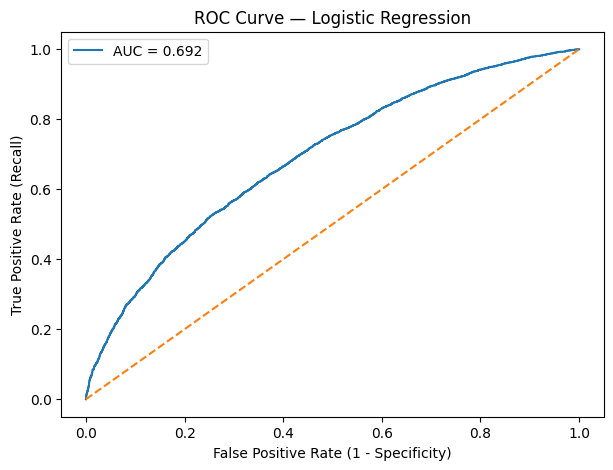

ROC AUC: 0.6922573907222959


In [11]:
y_test_binary = (y_test == positive).astype(int)

fpr, tpr, thresholds = roc_curve(y_test_binary, logit_prob)
roc_auc = roc_auc_score(y_test_binary, logit_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()

print("ROC AUC:", roc_auc)

### Precision-Recall Curve

Precision-recall curve sangat berguna ketika outcome positif relatif jarang. Kurva ini menunjukkan trade-off antara kemampuan menemukan kelas positif dan proporsi prediksi positif yang benar.

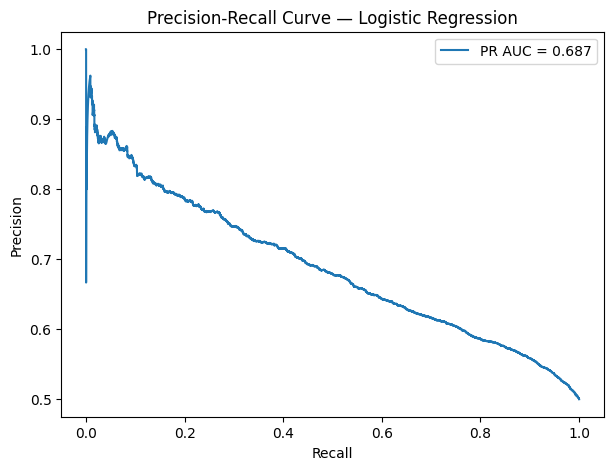

PR AUC: 0.6872378922746718


In [12]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test_binary, logit_prob
)
pr_auc = auc(recall_curve, precision_curve)

plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Logistic Regression")
plt.legend()
plt.show()

print("PR AUC:", pr_auc)

# 6. Mengubah Cutoff

Cutoff 0.50 bukan satu-satunya pilihan. Mengubah cutoff dapat meningkatkan recall dengan konsekuensi terhadap precision dan specificity.

Untuk aplikasi nyata, cutoff sebaiknya dikaitkan dengan biaya kesalahan klasifikasi dan tujuan bisnis, bukan dipilih hanya berdasarkan accuracy.

In [13]:
cutoffs = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
rows = []

for cutoff in cutoffs:
    pred_cut = np.where(logit_prob >= cutoff, positive, negative)
    cm_cut = confusion_matrix(y_test, pred_cut, labels=[negative, positive])
    tn, fp, fn, tp = cm_cut.ravel()

    rows.append({
        "cutoff": cutoff,
        "accuracy": (tp + tn) / (tp + tn + fp + fn),
        "precision": tp / (tp + fp) if tp + fp else 0,
        "recall": tp / (tp + fn) if tp + fn else 0,
        "specificity": tn / (tn + fp) if tn + fp else 0
    })

cutoff_table = pd.DataFrame(rows)
display(cutoff_table)

,cutoff,accuracy,precision,recall,specificity
0,0.2,0.519143,0.509857,0.990120,0.048165
1,0.3,0.571807,0.541311,0.940896,0.202717
2,0.4,0.615914,0.583609,0.809104,0.422724
3,0.5,0.634439,0.636903,0.625441,0.643437
4,0.6,0.621383,0.711302,0.408610,0.834157
5,0.7,0.573218,0.783470,0.202364,0.944072
6,0.8,0.524788,0.876676,0.057692,0.991884


# 7. Rare Class Problem / Imbalanced Data

Data klasifikasi dapat memiliki ketidakseimbangan kelas. Dalam contoh loan, kelas `default` dapat jauh lebih sedikit dibanding `paid off`.

Masalah utama: model dapat memperoleh accuracy tinggi hanya dengan memprediksi kelas mayoritas. Karena itu, evaluasi harus memperhatikan precision, recall, specificity, ROC/PR curve, dan konteks biaya kesalahan.

In [14]:
# Lihat ketidakseimbangan kelas pada data training logistic regression
imbalance = y_train.value_counts().rename("count").to_frame()
imbalance["proportion"] = imbalance["count"] / imbalance["count"].sum()
display(imbalance)

,count,proportion
outcome,,
paid off,17003,0.5
default,17003,0.5


## 7.1 Undersampling

**Undersampling/downsampling** menggunakan lebih sedikit record dari kelas dominan sehingga komposisi training data lebih seimbang.

Kelebihan:
- ukuran data training lebih kecil;
- dapat membantu eksplorasi/modeling pada data sangat besar.

Kekurangan:
- sebagian informasi dari kelas dominan dibuang.

In [15]:
# Contoh undersampling pada data training
train_bal = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)

min_count = train_bal[y_train.name].value_counts().min()
balanced_parts = []

for cls, group in train_bal.groupby(y_train.name):
    balanced_parts.append(group.sample(min_count, random_state=RANDOM_STATE))

train_under = pd.concat(balanced_parts).sample(frac=1, random_state=RANDOM_STATE)

display(train_under[y_train.name].value_counts())

,count
outcome,
default,17003
paid off,17003


## 7.2 Oversampling

**Oversampling/upsampling** menambah record dari kelas minoritas, biasanya dengan sampling with replacement.

Pendekatan ini mempertahankan lebih banyak data kelas mayoritas, tetapi record minoritas dapat diulang.

In [16]:
# Contoh oversampling sederhana pada training data
train_over_parts = []

max_count = train_bal[y_train.name].value_counts().max()

for cls, group in train_bal.groupby(y_train.name):
    train_over_parts.append(
        group.sample(max_count, replace=(len(group) < max_count),
                     random_state=RANDOM_STATE)
    )

train_over = pd.concat(train_over_parts).sample(frac=1, random_state=RANDOM_STATE)

display(train_over[y_train.name].value_counts())

,count
outcome,
default,17003
paid off,17003


## 7.3 Weighting

Weighting memberikan bobot lebih besar pada kelas yang lebih jarang. Pendekatan ini dapat menjadi alternatif terhadap undersampling dan oversampling.

Pada scikit-learn, bobot dapat diberikan melalui `sample_weight` pada model yang mendukungnya.

In [17]:
# Logistic regression dengan sample weights untuk memperbesar perhatian pada kelas minoritas
weights = np.where(y_train.to_numpy() == positive, 1 / np.mean(y_train == positive), 1.0)

weighted_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

weighted_model.fit(X_train, y_train, classifier__sample_weight=weights)

weighted_pred = weighted_model.predict(X_test)
weighted_prob = weighted_model.predict_proba(X_test)[:, list(weighted_model.classes_).index(positive)]

print("Weighted accuracy:", accuracy_score(y_test, weighted_pred))
print("Weighted recall:", recall_score(y_test, weighted_pred, pos_label=positive))
print("Weighted precision:", precision_score(y_test, weighted_pred, pos_label=positive))

Weighted accuracy: 0.590772759350741
Weighted recall: 0.9066690190543402
Weighted precision: 0.5556276354200455


## 7.4 Data Generation dan SMOTE

Chapter juga membahas data generation dan SMOTE sebagai pendekatan untuk membuat contoh sintetis dari kelas minoritas. Prinsipnya adalah memperkaya informasi kelas yang jarang, bukan sekadar menghapus data kelas mayoritas.

Implementasi SMOTE tidak diwajibkan pada notebook ini agar fokus tetap pada konsep yang direproduksi dari chapter.

# 8. Perbandingan Ringkas Metode

| Metode | Ide utama | Kelebihan | Catatan |
|---|---|---|---|
| Naive Bayes | Probabilitas kelas + conditional probability | Sederhana dan cepat | Asumsi independensi predictor |
| LDA | Kombinasi linear untuk memisahkan kelas | Batas keputusan linear dan interpretable | Mengandalkan asumsi distribusi/covariance |
| Logistic Regression | Memodelkan log odds | Probabilitas dan koefisien mudah dianalisis | Hubungan linear pada skala logit |

## Catatan perbandingan metode

Hasil accuracy dari Naive Bayes, LDA, dan Logistic Regression pada notebook ini berasal dari eksperimen dengan predictor dan split yang tidak sepenuhnya sama. Karena itu, hasil tersebut **tidak boleh dipakai sebagai ranking performa model**. Untuk perbandingan yang fair, gunakan dataset, train/test split, preprocessing, dan metrik yang sama untuk seluruh model.

# 9. Analisis dan Kesimpulan

## Analisis
1. Classification digunakan untuk memprediksi kategori/kelas berdasarkan predictor.
2. Naive Bayes menggunakan pendekatan probabilistik dan asumsi independensi bersyarat.
3. LDA membentuk fungsi diskriminan linear berdasarkan struktur covariance dan distribusi kelas.
4. Logistic regression memodelkan log odds outcome dan menghasilkan probabilitas kelas.
5. Confusion matrix menjadi dasar untuk menghitung accuracy, precision, recall, dan specificity.
6. ROC-AUC mengevaluasi kemampuan model membedakan dua kelas pada berbagai cutoff.
7. Pada data imbalanced, accuracy saja dapat menyesatkan sehingga metrik lain dan strategi balancing perlu diperhatikan.
8. Undersampling, oversampling, weighting, dan data generation/SMOTE merupakan strategi yang dibahas untuk menghadapi ketidakseimbangan kelas.

## Kesimpulan
Chapter 5 menunjukkan bahwa pemilihan dan evaluasi classifier harus disesuaikan dengan struktur data dan tujuan prediksi. Probabilitas prediksi, cutoff, jenis kesalahan, serta ketidakseimbangan kelas merupakan bagian penting dari proses klasifikasi.